# Linear and Quadratic Discriminant Analysis from Scratch

LDA and QDA are the same model with one assumption changed.

Both describe each class as a multivariate Gaussian cloud in feature space,

$$\mathbf{x} \mid y = c \;\sim\; \mathcal{N}(\boldsymbol\mu_c, \Sigma_c),$$

and classify a new point by picking the class with the highest posterior probability. The only difference is
what they allow the covariance to do:

- **QDA** fits a separate covariance $\Sigma_c$ for every class. Each class gets its own shape and orientation,
  and the boundary between any two classes is **quadratic**.
- **LDA** forces one shared covariance $\Sigma$ on all classes. The quadratic terms then become identical across
  classes and cancel in the argmax, leaving a discriminant that is **linear in $\mathbf{x}$**.

That cancellation is derived in full below. The same shared-covariance idea also gives LDA a second life as a
**supervised projection**: Fisher's discriminant directions, the eigenvectors of $S_W^{-1}S_B$, which compress
13 wine measurements down to 2 axes chosen specifically to spread the classes apart.

Everything here is written in NumPy. The only outside code is `ucimlrepo` for downloading the data and `pandas`
for holding it until it is converted to arrays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

SEED = 42
np.random.seed(SEED)

# one colour per cultivar, used everywhere below
CLASS_COLOURS = ['#2a78d6', '#eb6834', '#1baf7a']

print('numpy', np.__version__)

numpy 1.26.4


## The data

UCI Wine (`id=109`): 178 Italian wines from three cultivars grown in the same region, each described by 13
continuous chemical measurements — alcohol, flavanoids, colour intensity, proline and so on. There are no
missing values, and the classes are moderately unbalanced at roughly 59 / 71 / 48.

This is the standard test case for discriminant analysis because the classes are genuinely multivariate: no
single measurement separates all three, but linear combinations of them do so almost perfectly.

The next cell downloads the data, converts the features to a float array `X` and the cultivar labels to an
integer array `y` relabelled to `0, 1, 2`, and prints the class counts and the first few rows.

In [2]:
wine = fetch_ucirepo(id=109)

feature_names = list(wine.data.features.columns)
X_all = wine.data.features.to_numpy(dtype=float)
y_raw = wine.data.targets.to_numpy().ravel().astype(int)

# relabel cultivars 1,2,3 -> 0,1,2
classes = np.unique(y_raw)
y_all = np.searchsorted(classes, y_raw)
class_labels = ['Cultivar %d' % c for c in classes]

N, D = X_all.shape
C = len(classes)

print('X_all', X_all.shape, ' y_all', y_all.shape)
print('features:', feature_names)
print('missing values:', int(np.isnan(X_all).sum()))
for c in range(C):
    print('%-12s %3d wines' % (class_labels[c], np.sum(y_all == c)))
print()
print(wine.data.features.head())

X_all (178, 13)  y_all (178,)
features: ['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', '0D280_0D315_of_diluted_wines', 'Proline']
missing values: 0
Cultivar 1    59 wines
Cultivar 2    71 wines
Cultivar 3    48 wines

   Alcohol  Malicacid   Ash  Alcalinity_of_ash  Magnesium  Total_phenols  \
0    14.23       1.71  2.43               15.6        127           2.80   
1    13.20       1.78  2.14               11.2        100           2.65   
2    13.16       2.36  2.67               18.6        101           2.80   
3    14.37       1.95  2.50               16.8        113           3.85   
4    13.24       2.59  2.87               21.0        118           2.80   

   Flavanoids  Nonflavanoid_phenols  Proanthocyanins  Color_intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             

## Train/test split and standardisation

`split_data` shuffles the row indices with a fixed seed and takes 70% for training and 30% for testing. With
178 wines that leaves **53 test rows** and 125 training rows. 53 is small: a single misclassification moves test
accuracy by 1.9 points. Differences of one or two wines between LDA and QDA on this set are noise, so the honest
comparison comes later from the learning curve, not from a single split.

`standardise` computes the mean and standard deviation on the **training rows only** and applies them to both
splits. Using test statistics would leak information about the test set into the fit. Standardising is not
strictly required for discriminant analysis — the Mahalanobis distance is already scale-aware — but it puts
proline (values in the hundreds) and hue (values near 1) on a comparable numeric footing, which keeps the
covariance matrices better conditioned.

In [3]:
def split_data(X, y, test_frac=0.3, seed=SEED):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X))
    n_test = int(round(test_frac * len(X)))
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]


def standardise(X_train, X_test):
    mu = X_train.mean(axis=0)
    sd = X_train.std(axis=0)
    sd[sd == 0] = 1.0
    return (X_train - mu) / sd, (X_test - mu) / sd


X_train_raw, y_train, X_test_raw, y_test = split_data(X_all, y_all)
X_train, X_test = standardise(X_train_raw, X_test_raw)

print('train %d rows, test %d rows' % (len(X_train), len(X_test)))
for c in range(C):
    print('%-12s train %3d   test %3d' % (class_labels[c],
                                          np.sum(y_train == c),
                                          np.sum(y_test == c)))
print()
print('train feature means (should be ~0):', np.round(X_train.mean(axis=0), 12)[:5], '...')
print('train feature stds  (should be ~1):', np.round(X_train.std(axis=0), 12)[:5], '...')

train 125 rows, test 53 rows
Cultivar 1   train  40   test  19
Cultivar 2   train  50   test  21
Cultivar 3   train  35   test  13

train feature means (should be ~0): [ 0.  0.  0. -0.  0.] ...
train feature stds  (should be ~1): [1. 1. 1. 1. 1.] ...


## The shared model: a Gaussian per class

Both methods assume the features within a class follow a multivariate normal distribution:

$$P(\mathbf{x} \mid y=c) = \frac{1}{(2\pi)^{D/2}|\Sigma_c|^{1/2}}\exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol\mu_c)^\top \Sigma_c^{-1}(\mathbf{x}-\boldsymbol\mu_c)\right)$$

Bayes' rule turns this into a posterior,

$$P(y=c \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid y=c)\,\pi_c}{\sum_{k} P(\mathbf{x} \mid y=k)\,\pi_k},
\qquad \pi_c = \frac{N_c}{N},$$

and since the denominator is the same for every class, the prediction is the $c$ maximising the numerator.
Taking logs turns the product into a sum and cancels the exponential:

$$\log\big(P(\mathbf{x} \mid y=c)\,\pi_c\big) = -\tfrac{D}{2}\log 2\pi - \tfrac{1}{2}\log|\Sigma_c| - \tfrac{1}{2}(\mathbf{x}-\boldsymbol\mu_c)^\top\Sigma_c^{-1}(\mathbf{x}-\boldsymbol\mu_c) + \log\pi_c$$

The $-\tfrac{D}{2}\log 2\pi$ term does not depend on $c$, so it can be dropped. What remains is the **QDA
discriminant**:

$$\delta_c(\mathbf{x}) = -\tfrac{1}{2}\log|\Sigma_c| - \tfrac{1}{2}(\mathbf{x}-\boldsymbol\mu_c)^\top\Sigma_c^{-1}(\mathbf{x}-\boldsymbol\mu_c) + \log\pi_c$$

Predict $\hat{y} = \arg\max_c \delta_c(\mathbf{x})$.

### The Mahalanobis distance

The quadratic form in the middle,

$$d^2_{\Sigma}(\mathbf{x}, \boldsymbol\mu) = (\mathbf{x}-\boldsymbol\mu)^\top\Sigma^{-1}(\mathbf{x}-\boldsymbol\mu),$$

is the squared **Mahalanobis distance**. If $\Sigma = I$ it reduces to ordinary squared Euclidean distance.
In general, writing the eigendecomposition $\Sigma = V \Lambda V^\top$, it measures displacement along each
eigenvector of the covariance in units of that direction's standard deviation $\sqrt{\lambda_i}$. A point two
units away along a direction in which the class is very spread out is close; the same displacement along a
tight direction is far. Geometrically the level sets $d^2_\Sigma = \text{const}$ are ellipsoids aligned with
the class's own correlation structure, so the classifier is asking "how many class-sized steps away is this
point?" rather than "how many raw units away?".

QDA gives each class its own ellipsoid. LDA makes them all the same shape.

## Why the shared covariance makes the boundary linear

Set $\Sigma_c = \Sigma$ for every class and expand the quadratic form:

$$(\mathbf{x}-\boldsymbol\mu_c)^\top\Sigma^{-1}(\mathbf{x}-\boldsymbol\mu_c)
= \mathbf{x}^\top\Sigma^{-1}\mathbf{x} \;-\; 2\,\mathbf{x}^\top\Sigma^{-1}\boldsymbol\mu_c \;+\; \boldsymbol\mu_c^\top\Sigma^{-1}\boldsymbol\mu_c$$

(the two cross terms combine because $\Sigma^{-1}$ is symmetric, so $\mathbf{x}^\top\Sigma^{-1}\boldsymbol\mu_c = \boldsymbol\mu_c^\top\Sigma^{-1}\mathbf{x}$).

Substituting into the discriminant:

$$\delta_c(\mathbf{x}) = -\tfrac{1}{2}\log|\Sigma| \;\underbrace{-\;\tfrac{1}{2}\mathbf{x}^\top\Sigma^{-1}\mathbf{x}}_{\text{same for every }c} \;+\; \mathbf{x}^\top\Sigma^{-1}\boldsymbol\mu_c \;-\; \tfrac{1}{2}\boldsymbol\mu_c^\top\Sigma^{-1}\boldsymbol\mu_c \;+\; \log\pi_c$$

Two terms now carry no class index at all. The $-\tfrac{1}{2}\log|\Sigma|$ term is a constant, and
$-\tfrac{1}{2}\mathbf{x}^\top\Sigma^{-1}\mathbf{x}$ depends on $\mathbf{x}$ but is **identical for every class**,
because the same $\Sigma^{-1}$ appears in all of them. Adding the same quantity to every score cannot change
which score is largest, so both drop out of $\arg\max_c$. What survives is the **LDA discriminant**:

$$\delta_c(\mathbf{x}) = \mathbf{x}^\top\Sigma^{-1}\boldsymbol\mu_c - \tfrac{1}{2}\boldsymbol\mu_c^\top\Sigma^{-1}\boldsymbol\mu_c + \log\pi_c$$

This is $\mathbf{w}_c^\top\mathbf{x} + b_c$ with $\mathbf{w}_c = \Sigma^{-1}\boldsymbol\mu_c$ and
$b_c = -\tfrac{1}{2}\boldsymbol\mu_c^\top\Sigma^{-1}\boldsymbol\mu_c + \log\pi_c$ — **linear in $\mathbf{x}$**.
The boundary between classes $c$ and $k$ is the set where $\delta_c(\mathbf{x}) = \delta_k(\mathbf{x})$, i.e.
$(\mathbf{w}_c - \mathbf{w}_k)^\top\mathbf{x} + (b_c - b_k) = 0$: a hyperplane.

In QDA the covariances differ, so $-\tfrac{1}{2}\mathbf{x}^\top\Sigma_c^{-1}\mathbf{x}$ is a *different*
function of $\mathbf{x}$ for each class and does not cancel. The difference of two discriminants keeps a term
$-\tfrac{1}{2}\mathbf{x}^\top(\Sigma_c^{-1} - \Sigma_k^{-1})\mathbf{x}$, and the boundary is a quadric surface —
in 2-D an ellipse, parabola or hyperbola. That single algebraic fact is the entire difference between the two
methods, and it shows up directly in the decision-region plots later on.

### The pooled covariance

LDA's single $\Sigma$ is the within-class scatter averaged over all classes, each class centred on its own mean:

$$\Sigma = \frac{1}{N - C}\sum_{c=1}^{C}\sum_{i \in c}(\mathbf{x}_i - \boldsymbol\mu_c)(\mathbf{x}_i - \boldsymbol\mu_c)^\top$$

The divisor $N - C$ rather than $N$ accounts for the $C$ means already estimated from the data, making the
estimate unbiased. Note this is *not* the covariance of the whole dataset: that one would include the spread
of the class means themselves, which is exactly the between-class signal LDA wants to keep out of $\Sigma$.

## Turning the assumption off, gradually

The cancellation described above is easier to believe when you can watch it fail. The animation
below interpolates each class covariance from the shared pooled estimate to its own,

$$\Sigma_c(t) = (1-t)\,\bar\Sigma + t\,\Sigma_c$$

so $t=0$ is exactly LDA and $t=1$ is exactly QDA, with a continuum in between.

At $t=0$ every class ellipse is the same shape, the quadratic term
$-\tfrac{1}{2}x^\top(\Sigma_c^{-1} - \Sigma_k^{-1})x$ is identically zero, and the boundary is
straight. As $t$ rises the ellipses take on their own shapes and orientations and the boundary
bends into a conic. The boxed readout of $\max_{c,k} \lVert \Sigma_c^{-1} - \Sigma_k^{-1} \rVert_F$
turns the argument into a number: it is $0.00$ at $t=0$ and $15.89$ at $t=1$.

Both ends were checked against the classes above - at $t=0$ the animation's predictions match
`LDA` on the whole grid, and at $t=1$ they match `QDA`.

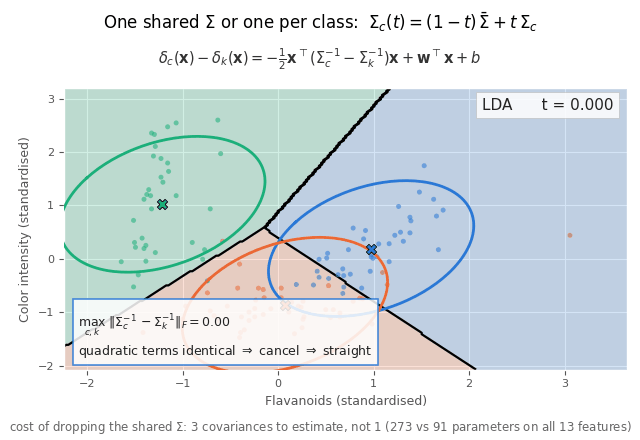

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/lda_qda_boundary.gif')

## Conditioning and the ridge

Inverting $\Sigma_c$ is where this model breaks in practice. A $13 \times 13$ covariance estimated from $N_c$
rows has rank at most $N_c - 1$, so it is singular whenever $N_c \le 13$ and nearly singular for $N_c$ not much
larger. The smallest cultivar contributes around 35 training rows here, and the learning-curve experiment
later shrinks that to fewer than 10 per class — well into the singular regime.

Both classes below therefore add a small ridge before inverting:

$$\tilde\Sigma_c = \Sigma_c + \varepsilon I, \qquad \varepsilon = 10^{-6}$$

This shifts every eigenvalue up by $\varepsilon$. Directions with real variance are untouched at the sixth
decimal place, but directions with zero estimated variance get a floor instead of dividing by zero, which
would otherwise send the Mahalanobis distance to infinity and produce `nan` scores. The **condition number**
$\kappa(\Sigma) = \lambda_{\max}/\lambda_{\min}$ measures how bad this is: values near 1 are well behaved,
values above roughly $10^{8}$ mean the inverse is dominated by numerical noise. Both are reported after fitting.

`log_det` and `mahalanobis` below do the numerical work. `np.linalg.slogdet` returns the log-determinant
directly, avoiding the underflow that computing $|\Sigma|$ and then taking a log would cause in 13 dimensions.
`mahalanobis` solves $\Sigma z = (\mathbf{x}-\boldsymbol\mu)^\top$ with `np.linalg.solve` rather than forming
$\Sigma^{-1}$ explicitly, which is both faster and more accurate, and then contracts the result row-wise.

In [4]:
RIDGE = 1e-6


def log_det(S):
    sign, logabsdet = np.linalg.slogdet(S)
    return logabsdet


def mahalanobis(X, mu, S):
    # squared Mahalanobis distance of every row of X from mu under covariance S
    diff = X - mu
    z = np.linalg.solve(S, diff.T).T
    return np.sum(diff * z, axis=1)


def class_covariance(Xc, mu):
    diff = Xc - mu
    return diff.T @ diff / max(len(Xc) - 1, 1)

## The QDA class

`QDA.fit` loops over the classes and stores, for each one, the prior $\pi_c = N_c/N$, the mean
$\boldsymbol\mu_c$, and the ridged covariance $\Sigma_c$. `QDA.decision_scores` evaluates

$$\delta_c(\mathbf{x}) = -\tfrac{1}{2}\log|\Sigma_c| - \tfrac{1}{2}d^2_{\Sigma_c}(\mathbf{x}, \boldsymbol\mu_c) + \log\pi_c$$

for every class and returns an $N \times C$ score matrix; `predict` takes the argmax along the class axis.
`predict_proba` exponentiates the scores after subtracting the row maximum — the usual softmax stabilisation,
which is exact here because the shift cancels in the normalisation — and recovers the posteriors.

The `diagonal` flag zeroes the off-diagonal entries of every $\Sigma_c$. That single change turns QDA into
Gaussian Naive Bayes, which is used later to make the connection concrete.

In [5]:
class QDA:

    def __init__(self, ridge=RIDGE, diagonal=False):
        self.ridge = ridge
        self.diagonal = diagonal

    def fit(self, X, y):
        self.classes = np.unique(y)
        n, d = X.shape
        self.means = np.zeros((len(self.classes), d))
        self.covs = np.zeros((len(self.classes), d, d))
        self.priors = np.zeros(len(self.classes))

        for i, c in enumerate(self.classes):
            Xc = X[y == c]
            mu = Xc.mean(axis=0)
            S = class_covariance(Xc, mu)
            if self.diagonal:
                S = np.diag(np.diag(S))          # Gaussian Naive Bayes
            S = S + self.ridge * np.eye(d)       # guard the inversion
            self.means[i] = mu
            self.covs[i] = S
            self.priors[i] = len(Xc) / n

        self.log_dets = np.array([log_det(S) for S in self.covs])
        return self

    def decision_scores(self, X):
        scores = np.zeros((len(X), len(self.classes)))
        for i in range(len(self.classes)):
            m2 = mahalanobis(X, self.means[i], self.covs[i])
            scores[:, i] = -0.5 * self.log_dets[i] - 0.5 * m2 + np.log(self.priors[i])
        return scores

    def predict(self, X):
        return self.classes[np.argmax(self.decision_scores(X), axis=1)]

    def predict_proba(self, X):
        s = self.decision_scores(X)
        s = s - s.max(axis=1, keepdims=True)
        e = np.exp(s)
        return e / e.sum(axis=1, keepdims=True)

    def condition_numbers(self):
        return np.array([np.linalg.cond(S) for S in self.covs])

## The LDA class

`LDA.fit` estimates the same class means but accumulates a single pooled covariance from the summed
within-class scatter divided by $N - C$, then converts it to the linear form derived above:

- `self.weights[i]` $= \Sigma^{-1}\boldsymbol\mu_c$
- `self.biases[i]` $= -\tfrac{1}{2}\boldsymbol\mu_c^\top\Sigma^{-1}\boldsymbol\mu_c + \log\pi_c$

so `decision_scores` is a single matrix product `X @ weights.T + biases` — no per-class quadratic form is
evaluated at all, which is the computational payoff of the cancellation.

The same method also builds the Fisher projection. `self.scatter_within` is $S_W$ (the unnormalised pooled
scatter), `self.scatter_between` is $S_B$, and `self.components` holds the leading eigenvectors of
$S_W^{-1}S_B$, with `self.eigenvalues` the corresponding eigenvalues. `transform` centres the data on the
global mean and projects it onto those directions. The maths behind this is set out in the next section.

In [6]:
class LDA:

    def __init__(self, ridge=RIDGE, n_components=None):
        self.ridge = ridge
        self.n_components = n_components

    def fit(self, X, y):
        self.classes = np.unique(y)
        n, d = X.shape
        k = len(self.classes)

        self.means = np.zeros((k, d))
        self.priors = np.zeros(k)
        self.counts = np.zeros(k)
        self.overall_mean = X.mean(axis=0)

        Sw = np.zeros((d, d))
        Sb = np.zeros((d, d))

        for i, c in enumerate(self.classes):
            Xc = X[y == c]
            mu = Xc.mean(axis=0)
            diff = Xc - mu
            Sw += diff.T @ diff                                   # within-class scatter
            mdiff = (mu - self.overall_mean).reshape(-1, 1)
            Sb += len(Xc) * (mdiff @ mdiff.T)                      # between-class scatter
            self.means[i] = mu
            self.counts[i] = len(Xc)
            self.priors[i] = len(Xc) / n

        self.scatter_within = Sw
        self.scatter_between = Sb

        # pooled covariance: within-class scatter divided by N - C, plus ridge
        self.covariance = Sw / (n - k) + self.ridge * np.eye(d)

        # linear discriminant: w_c = Sigma^-1 mu_c, b_c = -0.5 mu_c^T Sigma^-1 mu_c + log pi_c
        self.weights = np.linalg.solve(self.covariance, self.means.T).T
        self.biases = -0.5 * np.sum(self.means * self.weights, axis=1) + np.log(self.priors)

        self._fit_fisher(Sw, Sb, d, k)
        return self

    def _fit_fisher(self, Sw, Sb, d, k):
        # eigenvectors of Sw^-1 Sb, ordered by decreasing eigenvalue
        M = np.linalg.solve(Sw + self.ridge * np.eye(d), Sb)
        vals, vecs = np.linalg.eig(M)
        vals = np.real(vals)
        vecs = np.real(vecs)
        order = np.argsort(vals)[::-1]
        vals = vals[order]
        vecs = vecs[:, order]
        vecs = vecs / np.linalg.norm(vecs, axis=0, keepdims=True)

        self.eigenvalues = vals
        n_comp = self.n_components if self.n_components is not None else k - 1
        self.components = vecs[:, :n_comp]

    def transform(self, X):
        return (X - self.overall_mean) @ self.components

    def decision_scores(self, X):
        return X @ self.weights.T + self.biases

    def predict(self, X):
        return self.classes[np.argmax(self.decision_scores(X), axis=1)]

    def predict_proba(self, X):
        s = self.decision_scores(X)
        s = s - s.max(axis=1, keepdims=True)
        e = np.exp(s)
        return e / e.sum(axis=1, keepdims=True)

    def condition_number(self):
        return np.linalg.cond(self.covariance)

## Fitting both on all 13 features

`accuracy` counts exact label matches. The next cell fits `LDA` and `QDA` on the standardised training rows,
scores both on train and test, and prints the condition numbers of the pooled covariance and of each per-class
covariance.

In [7]:
def accuracy(y_true, y_pred):
    return float(np.mean(y_true == y_pred))


lda = LDA().fit(X_train, y_train)
qda = QDA().fit(X_train, y_train)

lda_train_acc = accuracy(y_train, lda.predict(X_train))
lda_test_acc = accuracy(y_test, lda.predict(X_test))
qda_train_acc = accuracy(y_train, qda.predict(X_train))
qda_test_acc = accuracy(y_test, qda.predict(X_test))

print('              train      test')
print('LDA         %7.4f   %7.4f' % (lda_train_acc, lda_test_acc))
print('QDA         %7.4f   %7.4f' % (qda_train_acc, qda_test_acc))
print()
print('test set size: %d wines  (1 error = %.2f accuracy points)'
      % (len(y_test), 100.0 / len(y_test)))
print()
print('condition numbers')
print('  pooled Sigma        %12.2f' % lda.condition_number())
for i, c in enumerate(qda.classes):
    print('  Sigma[%s]  %12.2f   (n = %d)'
          % (class_labels[c], qda.condition_numbers()[i], np.sum(y_train == c)))

              train      test
LDA          1.0000    1.0000
QDA          0.9920    0.9811

test set size: 53 wines  (1 error = 1.89 accuracy points)

condition numbers
  pooled Sigma               19.69
  Sigma[Cultivar 1]        132.48   (n = 40)
  Sigma[Cultivar 2]         78.14   (n = 50)
  Sigma[Cultivar 3]        151.85   (n = 35)


## Parameter counts

A symmetric $D \times D$ covariance has $D(D+1)/2$ free entries — the diagonal plus one triangle.

- **LDA** estimates one of them: $D(D+1)/2$ covariance parameters.
- **QDA** estimates one per class: $C \cdot D(D+1)/2$.

For the wine data, $D = 13$ and $C = 3$:

$$\text{LDA:} \quad \frac{13 \cdot 14}{2} = 91 \qquad\qquad \text{QDA:} \quad 3 \cdot \frac{13 \cdot 14}{2} = 273$$

Adding the $C \cdot D = 39$ mean parameters and $C - 1 = 2$ free priors gives 132 for LDA and 314 for QDA. QDA
has roughly 2.4 times as many parameters to estimate, and it estimates each covariance from only the rows of
one class — about 35 to 50 rows here — instead of pooling all 124. Fewer rows per parameter means noisier
estimates, which is why QDA needs more data and starts overfitting sooner. The learning curve at the end of the
notebook measures exactly this.

Gaussian Naive Bayes sits at the other end: forcing every $\Sigma_c$ diagonal drops the count to $C \cdot D = 39$
covariance parameters, cheap to estimate but blind to correlations between features.

In [8]:
cov_params_lda = D * (D + 1) // 2
cov_params_qda = C * D * (D + 1) // 2
cov_params_gnb = C * D
mean_params = C * D
prior_params = C - 1

print('D = %d features, C = %d classes, %d training rows' % (D, C, len(X_train)))
print()
print('%-22s %10s %8s %8s %8s' % ('model', 'covariance', 'means', 'priors', 'total'))
for name, cp in [('LDA (pooled)', cov_params_lda),
                 ('QDA (per class)', cov_params_qda),
                 ('Gaussian NB (diagonal)', cov_params_gnb)]:
    print('%-22s %10d %8d %8d %8d' % (name, cp, mean_params, prior_params,
                                      cp + mean_params + prior_params))
print()
print('QDA / LDA covariance parameters: %.1fx' % (cov_params_qda / cov_params_lda))
print('training rows per covariance parameter: LDA %.2f, QDA %.2f'
      % (len(X_train) / cov_params_lda, len(X_train) / cov_params_qda))

D = 13 features, C = 3 classes, 125 training rows

model                  covariance    means   priors    total
LDA (pooled)                   91       39        2      132
QDA (per class)               273       39        2      314
Gaussian NB (diagonal)         39       39        2       80

QDA / LDA covariance parameters: 3.0x
training rows per covariance parameter: LDA 1.37, QDA 0.46


## Gaussian Naive Bayes is QDA with diagonal covariances

Naive Bayes assumes the features are conditionally independent given the class,
$P(\mathbf{x} \mid y=c) = \prod_{j} P(x_j \mid y=c)$. When each factor is a univariate Gaussian, the product is
a multivariate Gaussian whose covariance has zeros everywhere off the diagonal. So Gaussian Naive Bayes is not
a different model — it is QDA with $\Sigma_c$ restricted to $\mathrm{diag}(\sigma^2_{c1}, \dots, \sigma^2_{cD})$.

The Mahalanobis distance then collapses to a sum of per-feature terms,
$\sum_j (x_j - \mu_{cj})^2 / \sigma^2_{cj}$, and the contours become axis-aligned ellipsoids. The boundary is
still quadratic, so Naive Bayes is a constrained QDA rather than a constrained LDA.

The cell below fits `QDA(diagonal=True)` and compares, and also measures how much correlation the diagonal
assumption throws away. Wine features are genuinely correlated — flavanoids, total phenols and the OD280
measurement move together — so the independence assumption is false here. It is nevertheless not punished on
this data: dropping to 39 covariance parameters removes almost all of the estimation noise that full QDA
suffers from at 125 rows, and the two effects roughly cancel on a 53-wine test set. A wrong assumption that
buys a large variance reduction is a familiar trade, and it is the same trade LDA is making in milder form.

In [9]:
gnb = QDA(diagonal=True).fit(X_train, y_train)

print('Gaussian NB (QDA with diagonal covariances)')
print('  train %.4f   test %.4f' % (accuracy(y_train, gnb.predict(X_train)),
                                    accuracy(y_test, gnb.predict(X_test))))
print()

# how much correlation is being thrown away
full_cov = qda.covs[0]
sd = np.sqrt(np.diag(full_cov))
corr = full_cov / np.outer(sd, sd)
off = corr[~np.eye(D, dtype=bool)]
print('%s feature correlations: mean |r| = %.3f, max |r| = %.3f'
      % (class_labels[0], np.mean(np.abs(off)), np.max(np.abs(off))))

Gaussian NB (QDA with diagonal covariances)
  train 0.9760   test 1.0000

Cultivar 1 feature correlations: mean |r| = 0.253, max |r| = 0.837


## LDA as a projection: Fisher's discriminants

The same shared-covariance assumption gives a supervised dimensionality reduction. Split the total scatter of
the data into two pieces:

$$S_W = \sum_c \sum_{i \in c}(\mathbf{x}_i - \boldsymbol\mu_c)(\mathbf{x}_i - \boldsymbol\mu_c)^\top,
\qquad
S_B = \sum_c N_c(\boldsymbol\mu_c - \boldsymbol\mu)(\boldsymbol\mu_c - \boldsymbol\mu)^\top$$

$S_W$ is how much the wines scatter around their own cultivar's mean; $S_B$ is how much the cultivar means
scatter around the global mean $\boldsymbol\mu$. Note $S_W = (N - C)\,\Sigma$, so this is the pooled covariance
again, unnormalised.

A good projection direction $\mathbf{w}$ spreads the class means apart while keeping each class tight, which is
Fisher's criterion — a ratio of the two scatters measured along $\mathbf{w}$:

$$J(\mathbf{w}) = \frac{\mathbf{w}^\top S_B \mathbf{w}}{\mathbf{w}^\top S_W \mathbf{w}}$$

Setting the gradient to zero gives $S_B\mathbf{w} = \lambda S_W \mathbf{w}$, a generalised eigenvalue problem,
or equivalently the ordinary eigenproblem

$$S_W^{-1}S_B\,\mathbf{w} = \lambda\,\mathbf{w}$$

The eigenvector with the largest eigenvalue is the most discriminative direction, and $\lambda$ is the value of
$J$ achieved along it. `LDA._fit_fisher` builds $S_W^{-1}S_B$ with `np.linalg.solve`, calls `np.linalg.eig`,
and sorts by decreasing eigenvalue. `np.linalg.eig` is used rather than `eigh` because the product of two
symmetric matrices is not itself symmetric; the eigenvalues are real in theory, and `np.real` discards the
tiny imaginary parts left by floating-point arithmetic.

### Why there are at most $C-1$ discriminants

$S_B$ is a sum of $C$ rank-one terms $N_c(\boldsymbol\mu_c - \boldsymbol\mu)(\boldsymbol\mu_c - \boldsymbol\mu)^\top$,
so $\mathrm{rank}(S_B) \le C$. But the $C$ deviation vectors are not independent: by construction
$\sum_c N_c(\boldsymbol\mu_c - \boldsymbol\mu) = \mathbf{0}$, since $\boldsymbol\mu$ is the weighted average of
the class means. One linear constraint removes one dimension, so $\mathrm{rank}(S_B) \le C - 1$, and therefore
$\mathrm{rank}(S_W^{-1}S_B) \le C-1$ as well. Every remaining eigenvalue is exactly zero — those directions
carry no between-class separation at all.

With $C = 3$ cultivars, **at most 2 discriminants are useful**, whatever the number of features. That is a
lucky coincidence for plotting: the full 13-dimensional structure that LDA can see reduces to exactly a 2-D
scatter plot with no information lost. The eigenvalue spectrum below confirms it.

In [10]:
eigvals = lda.eigenvalues
print('eigenvalues of Sw^-1 Sb (top 6):')
for i in range(6):
    print('  lambda_%d = %12.6f' % (i + 1, eigvals[i]))
print()
print('rank bound C - 1 = %d' % (C - 1))
print('sum of first %d eigenvalues / total = %.6f'
      % (C - 1, eigvals[:C - 1].sum() / eigvals.sum()))
print('largest eigenvalue beyond the first %d: %.3e' % (C - 1, np.abs(eigvals[C - 1:]).max()))
print()
print('rank(Sb) = %d,  rank(Sw) = %d'
      % (np.linalg.matrix_rank(lda.scatter_between), np.linalg.matrix_rank(lda.scatter_within)))

eigenvalues of Sw^-1 Sb (top 6):
  lambda_1 =     9.095426
  lambda_2 =     3.969579
  lambda_3 =     0.000000
  lambda_4 =     0.000000
  lambda_5 =     0.000000
  lambda_6 =     0.000000

rank bound C - 1 = 2
sum of first 2 eigenvalues / total = 1.000000
largest eigenvalue beyond the first 2: 1.166e-15

rank(Sb) = 2,  rank(Sw) = 13


### Figure 1: the eigenvalue spectrum

Bar chart of all 13 eigenvalues of $S_W^{-1}S_B$ on a log scale, with the $C-1$ cut-off marked. Only the first
two should rise above the numerical floor; the remaining eleven sit at machine-precision noise around zero,
which is the rank argument above shown numerically.

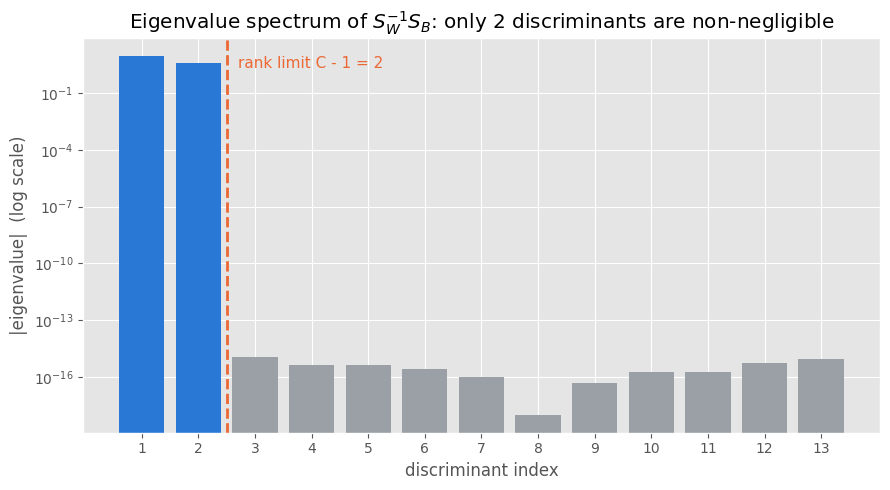

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

vals_plot = np.maximum(np.abs(eigvals), 1e-18)
bar_colours = [CLASS_COLOURS[0] if i < C - 1 else '#9aa0a6' for i in range(D)]
ax.bar(np.arange(1, D + 1), vals_plot, color=bar_colours)
ax.set_yscale('log')
ax.axvline(C - 1 + 0.5, color='#eb6834', linestyle='--', linewidth=2)
ax.text(C - 1 + 0.7, vals_plot.max(), 'rank limit C - 1 = %d' % (C - 1),
        color='#eb6834', va='top', fontsize=11)
ax.set_xlabel('discriminant index')
ax.set_ylabel('|eigenvalue|  (log scale)')
ax.set_title('Eigenvalue spectrum of $S_W^{-1}S_B$: only %d discriminants are non-negligible' % (C - 1))
ax.set_xticks(np.arange(1, D + 1))
plt.tight_layout()
plt.show()

### Figure 2: the LDA projection

Left panel: the 13-dimensional training data projected onto the first two Fisher discriminants via
`lda.transform`. Right panel: the same wines plotted against two raw standardised features, alcohol and
flavanoids, for comparison. Both panels show two axes of the same data — the difference is only in how the
axes were chosen, one by supervised optimisation of $J(\mathbf{w})$ and one arbitrarily.

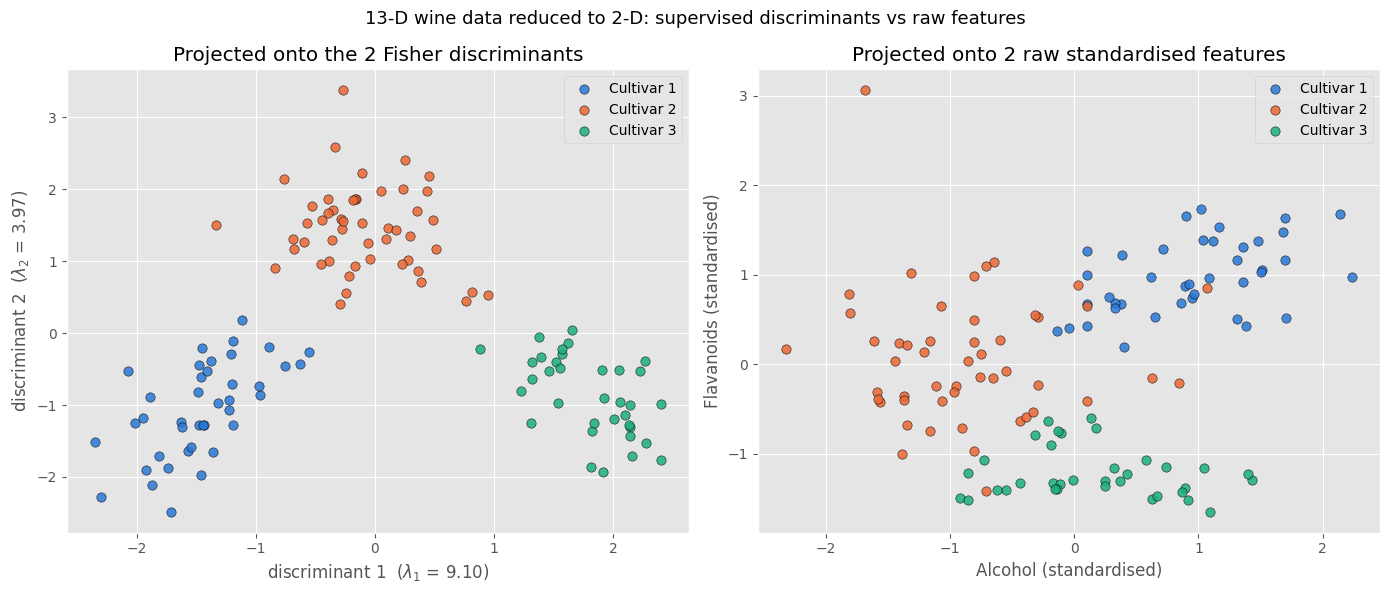

In [12]:
Z_train = lda.transform(X_train)
Z_test = lda.transform(X_test)

alc = feature_names.index('Alcohol')
flav = feature_names.index('Flavanoids')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for c in range(C):
    m = y_train == c
    axes[0].scatter(Z_train[m, 0], Z_train[m, 1], s=45, alpha=0.85,
                    color=CLASS_COLOURS[c], edgecolor='k', linewidth=0.4,
                    label=class_labels[c])
axes[0].set_xlabel('discriminant 1  ($\\lambda_1$ = %.2f)' % eigvals[0])
axes[0].set_ylabel('discriminant 2  ($\\lambda_2$ = %.2f)' % eigvals[1])
axes[0].set_title('Projected onto the 2 Fisher discriminants')
axes[0].legend(loc='best')

for c in range(C):
    m = y_train == c
    axes[1].scatter(X_train[m, alc], X_train[m, flav], s=45, alpha=0.85,
                    color=CLASS_COLOURS[c], edgecolor='k', linewidth=0.4,
                    label=class_labels[c])
axes[1].set_xlabel('Alcohol (standardised)')
axes[1].set_ylabel('Flavanoids (standardised)')
axes[1].set_title('Projected onto 2 raw standardised features')
axes[1].legend(loc='best')

fig.suptitle('13-D wine data reduced to 2-D: supervised discriminants vs raw features', fontsize=13)
plt.tight_layout()
plt.show()

The next cell quantifies the difference with the same criterion the discriminants were chosen to maximise: for
each 2-D representation it computes the trace ratio $\mathrm{tr}(S_B)/\mathrm{tr}(S_W)$ of the projected data,
and also fits an LDA classifier restricted to those two coordinates.

In [13]:
def separation_ratio(Z, y):
    # trace(Sb) / trace(Sw) for a projected representation
    overall = Z.mean(axis=0)
    sw = 0.0
    sb = 0.0
    for c in np.unique(y):
        Zc = Z[y == c]
        mu = Zc.mean(axis=0)
        sw += np.sum((Zc - mu) ** 2)
        sb += len(Zc) * np.sum((mu - overall) ** 2)
    return sb / sw


raw_pair_train = X_train[:, [alc, flav]]
raw_pair_test = X_test[:, [alc, flav]]

lda_on_disc = LDA().fit(Z_train, y_train)
lda_on_raw = LDA().fit(raw_pair_train, y_train)

print('trace(Sb)/trace(Sw) on the 2-D representation')
print('  Fisher discriminants  %.3f' % separation_ratio(Z_train, y_train))
print('  raw Alcohol/Flavanoids %.3f' % separation_ratio(raw_pair_train, y_train))
print()
print('LDA test accuracy using only those 2 coordinates')
print('  Fisher discriminants  %.4f' % accuracy(y_test, lda_on_disc.predict(Z_test)))
print('  raw Alcohol/Flavanoids %.4f' % accuracy(y_test, lda_on_raw.predict(raw_pair_test)))
print()
print('LDA test accuracy on all %d features  %.4f' % (D, lda_test_acc))

trace(Sb)/trace(Sw) on the 2-D representation
  Fisher discriminants  5.672
  raw Alcohol/Flavanoids 1.887

LDA test accuracy using only those 2 coordinates
  Fisher discriminants  1.0000
  raw Alcohol/Flavanoids 0.9057

LDA test accuracy on all 13 features  1.0000


### Figure 3: straight boundaries versus curved ones

This is the direct visual consequence of the cancellation derived earlier. Both classifiers are refitted on
just two features — flavanoids and colour intensity — so the decision regions can be drawn in the plane.
`decision_grid` evaluates each model over a mesh spanning the data and returns the predicted class at every
grid point; `contourf` shades the regions and the training wines are scattered on top.

LDA's regions are separated by straight lines, because the boundary between classes $c$ and $k$ solves the
linear equation $(\mathbf{w}_c - \mathbf{w}_k)^\top\mathbf{x} + (b_c - b_k) = 0$. QDA's are separated by
conic sections, because the term $-\tfrac{1}{2}\mathbf{x}^\top(\Sigma_c^{-1} - \Sigma_k^{-1})\mathbf{x}$
survives in the difference of discriminants.

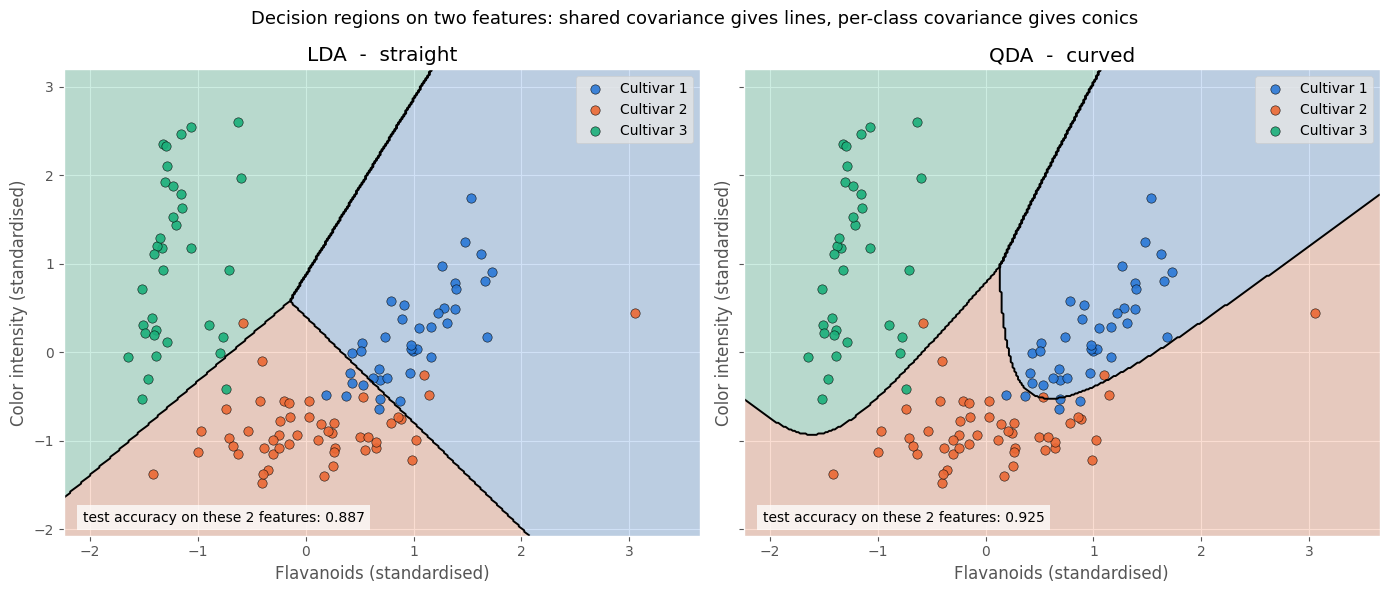

In [14]:
def decision_grid(model, X2, pad=0.6, steps=350):
    x_min, x_max = X2[:, 0].min() - pad, X2[:, 0].max() + pad
    y_min, y_max = X2[:, 1].min() - pad, X2[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, steps),
                         np.linspace(y_min, y_max, steps))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = model.predict(grid).reshape(xx.shape)
    return xx, yy, zz


f1 = feature_names.index('Flavanoids')
f2 = feature_names.index('Color_intensity')
pair_train = X_train[:, [f1, f2]]
pair_test = X_test[:, [f1, f2]]

lda2 = LDA().fit(pair_train, y_train)
qda2 = QDA().fit(pair_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, model, name in [(axes[0], lda2, 'LDA'), (axes[1], qda2, 'QDA')]:
    xx, yy, zz = decision_grid(model, pair_train)
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5, 2.5], colors=CLASS_COLOURS, alpha=0.22)
    ax.contour(xx, yy, zz, levels=[0.5, 1.5], colors='k', linewidths=1.4)
    for c in range(C):
        m = y_train == c
        ax.scatter(pair_train[m, 0], pair_train[m, 1], s=45, alpha=0.9,
                   color=CLASS_COLOURS[c], edgecolor='k', linewidth=0.4,
                   label=class_labels[c])
    acc2 = accuracy(y_test, model.predict(pair_test))
    ax.set_xlabel('Flavanoids (standardised)')
    ax.set_ylabel('Color intensity (standardised)')
    ax.set_title('%s  -  straight' % name if name == 'LDA' else '%s  -  curved' % name)
    ax.text(0.03, 0.03, 'test accuracy on these 2 features: %.3f' % acc2,
            transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
    ax.legend(loc='upper right')

fig.suptitle('Decision regions on two features: shared covariance gives lines, per-class covariance gives conics',
             fontsize=13)
plt.tight_layout()
plt.show()

### Figure 4: is the equal-covariance assumption reasonable?

LDA is only justified when the three classes really do have the same covariance. This figure checks that
directly on the same two features. `cov_ellipse` takes a $2 \times 2$ covariance and a mean, eigendecomposes
the covariance with `np.linalg.eigh`, and traces the ellipse
$\{\boldsymbol\mu + s\,V\Lambda^{1/2}\mathbf{u} : \|\mathbf{u}\| = 1\}$, which is the contour of constant
Mahalanobis distance $s$. The eigenvector directions give the ellipse axes and $\sqrt{\lambda_i}$ give the
semi-axis lengths, so the drawn shape *is* the class's Gaussian at 2 standard deviations.

Three coloured ellipses show the per-class covariances QDA fits; the dashed black ellipse is the single pooled
covariance LDA uses for all of them. Where the coloured ellipses differ in size or orientation, LDA's
assumption is violated and QDA has something real to exploit.

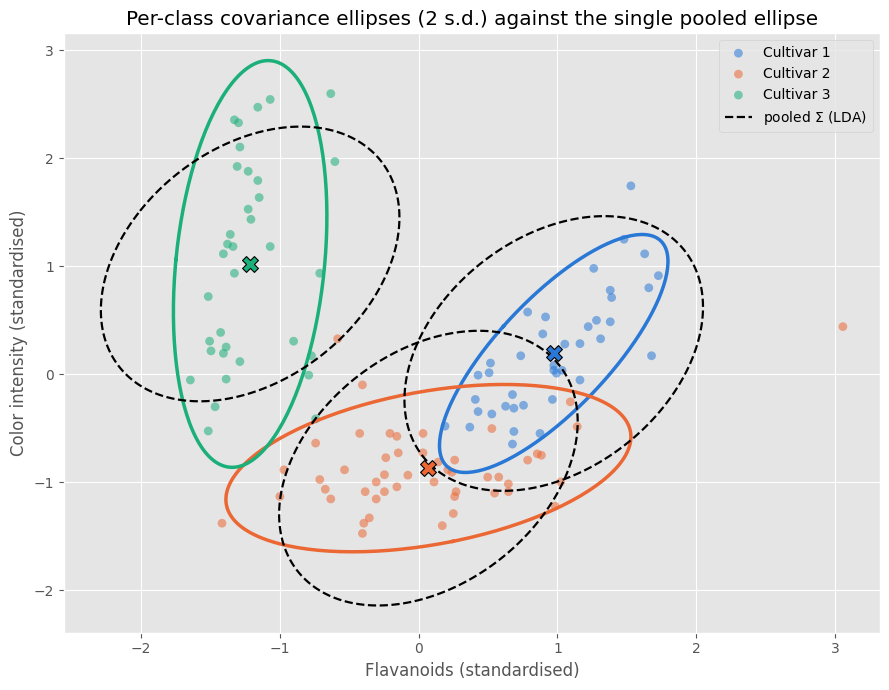

per-class 2x2 covariances on these two features
  Cultivar 1   var = [0.169 0.303]  corr = +0.773  |S| = 0.0207
  Cultivar 2   var = [0.532 0.150]  corr = +0.375  |S| = 0.0686
  Cultivar 3   var = [0.076 0.886]  corr = +0.235  |S| = 0.0640
  pooled       var = [0.289 0.404]  corr = +0.338  |S| = 0.1035


In [15]:
def cov_ellipse(mu, S, n_std=2.0, points=200):
    vals, vecs = np.linalg.eigh(S)
    vals = np.maximum(vals, 0.0)
    t = np.linspace(0, 2 * np.pi, points)
    circle = np.column_stack([np.cos(t), np.sin(t)])
    pts = circle @ (vecs * np.sqrt(vals)).T * n_std
    return pts + mu


fig, ax = plt.subplots(figsize=(9, 7))

for c in range(C):
    m = y_train == c
    ax.scatter(pair_train[m, 0], pair_train[m, 1], s=40, alpha=0.55,
               color=CLASS_COLOURS[c], edgecolor='none', label=class_labels[c])
    e = cov_ellipse(qda2.means[c], qda2.covs[c])
    ax.plot(e[:, 0], e[:, 1], color=CLASS_COLOURS[c], linewidth=2.5)
    ax.scatter([qda2.means[c][0]], [qda2.means[c][1]], marker='X', s=130,
               color=CLASS_COLOURS[c], edgecolor='k', linewidth=0.8, zorder=5)

for c in range(C):
    e = cov_ellipse(lda2.means[c], lda2.covariance)
    ax.plot(e[:, 0], e[:, 1], color='k', linestyle='--', linewidth=1.6,
            label='pooled $\\Sigma$ (LDA)' if c == 0 else None)

ax.set_xlabel('Flavanoids (standardised)')
ax.set_ylabel('Color intensity (standardised)')
ax.set_title('Per-class covariance ellipses (2 s.d.) against the single pooled ellipse')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print('per-class 2x2 covariances on these two features')
for c in range(C):
    S = qda2.covs[c]
    corr = S[0, 1] / np.sqrt(S[0, 0] * S[1, 1])
    print('  %-12s var = [%.3f %.3f]  corr = %+.3f  |S| = %.4f'
          % (class_labels[c], S[0, 0], S[1, 1], corr, np.linalg.det(S)))
Sp = lda2.covariance
print('  %-12s var = [%.3f %.3f]  corr = %+.3f  |S| = %.4f'
      % ('pooled', Sp[0, 0], Sp[1, 1], Sp[0, 1] / np.sqrt(Sp[0, 0] * Sp[1, 1]), np.linalg.det(Sp)))

### Figure 5: confusion matrices

`confusion_matrix` counts test predictions into a $C \times C$ table with true cultivar on the rows and
predicted cultivar on the columns, so the diagonal holds correct predictions. Both matrices use the full
13-feature models and every cell is annotated with its count.

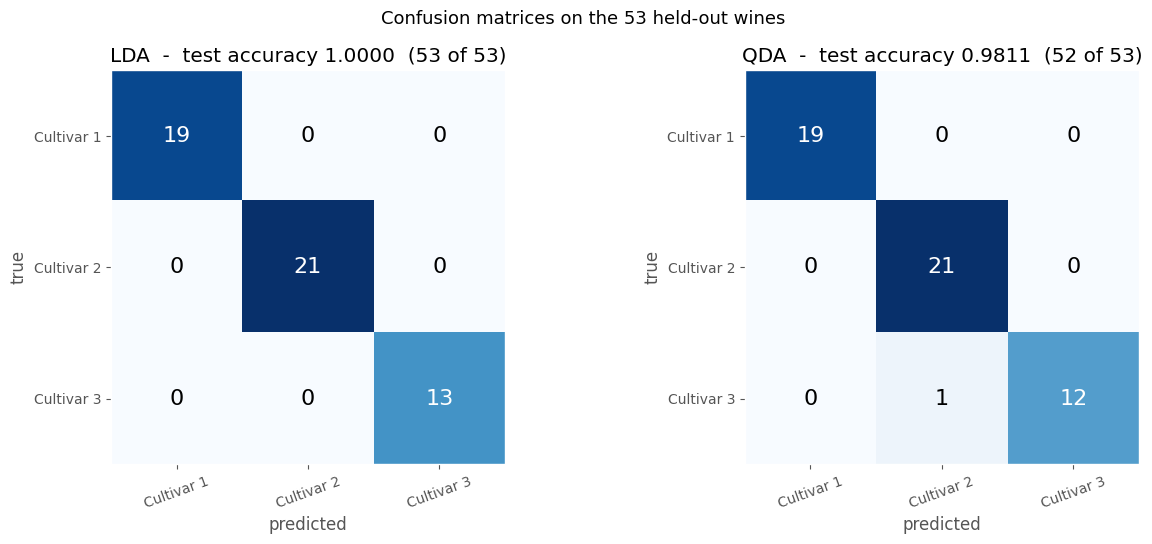

LDA confusion matrix
 [[19  0  0]
 [ 0 21  0]
 [ 0  0 13]]
QDA confusion matrix
 [[19  0  0]
 [ 0 21  0]
 [ 0  1 12]]


In [16]:
def confusion_matrix(y_true, y_pred, n_classes):
    M = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        M[t, p] += 1
    return M


cm_lda = confusion_matrix(y_test, lda.predict(X_test), C)
cm_qda = confusion_matrix(y_test, qda.predict(X_test), C)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, cm, name, acc in [(axes[0], cm_lda, 'LDA', lda_test_acc),
                          (axes[1], cm_qda, 'QDA', qda_test_acc)]:
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())
    for i in range(C):
        for j in range(C):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16,
                    color='white' if cm[i, j] > cm.max() * 0.55 else 'black')
    ax.set_xticks(range(C))
    ax.set_yticks(range(C))
    ax.set_xticklabels(class_labels, rotation=20)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.set_title('%s  -  test accuracy %.4f  (%d of %d)'
                 % (name, acc, int(np.trace(cm)), len(y_test)))
    ax.grid(False)

fig.suptitle('Confusion matrices on the %d held-out wines' % len(y_test), fontsize=13)
plt.tight_layout()
plt.show()

print('LDA confusion matrix\n', cm_lda)
print('QDA confusion matrix\n', cm_qda)

### Figure 6: accuracy against training-set size

A single 54-wine test set cannot separate two classifiers that both sit near the ceiling. The parameter counts
predict a difference that only appears when data is scarce, and this experiment looks for it.

`stratified_subsample` draws a training subset of a requested size while keeping the class proportions, so no
class disappears. For each size, `learning_curve` repeats the whole procedure over 25 random draws and averages
the test accuracy of both models. The test set is held fixed throughout, so only the amount of training data
changes.

At the smallest sizes each class contributes fewer than 10 rows to a $13 \times 13$ covariance, which is deeply
rank-deficient — this is where the ridge is doing real work, and where QDA's 273 covariance parameters are being
estimated from almost nothing. LDA pools every row into a single covariance, so its estimate stays full rank as
soon as the total exceeds $D$, whichever class the rows came from.

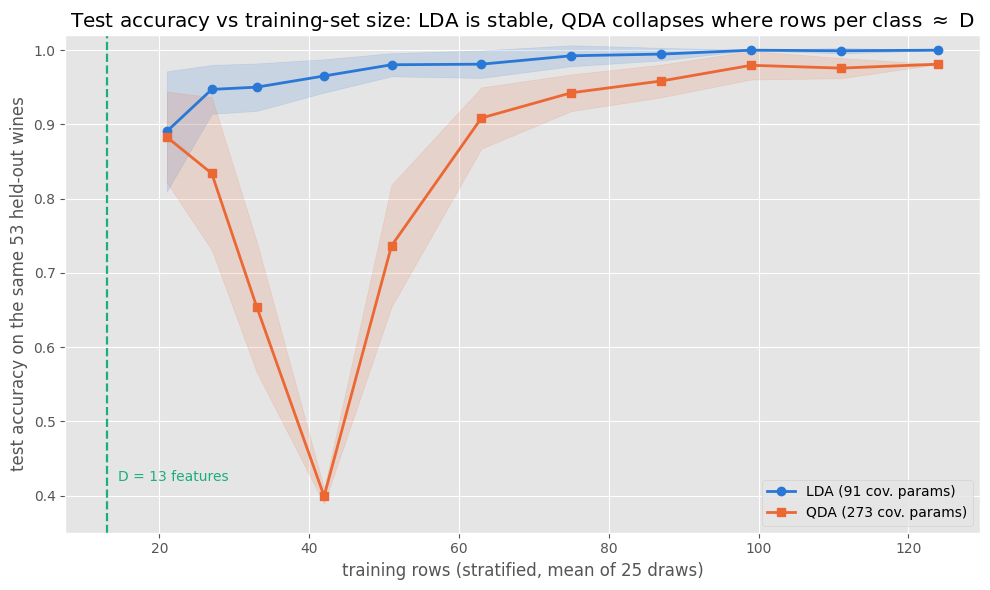

 n_train            LDA            QDA        gap
      21   0.8906+-0.081   0.8830+-0.061   +0.0075
      27   0.9472+-0.033   0.8340+-0.103   +0.1132
      33   0.9502+-0.032   0.6543+-0.088   +0.2958
      42   0.9653+-0.022   0.3992+-0.010   +0.5660
      51   0.9804+-0.016   0.7366+-0.082   +0.2438
      63   0.9811+-0.018   0.9087+-0.041   +0.0725
      75   0.9925+-0.014   0.9426+-0.025   +0.0498
      87   0.9947+-0.008   0.9585+-0.022   +0.0362
      99   1.0000+-0.000   0.9796+-0.019   +0.0204
     111   0.9992+-0.004   0.9758+-0.014   +0.0234
     124   1.0000+-0.000   0.9811+-0.000   +0.0189


In [17]:
def stratified_subsample(X, y, n_total, rng):
    idx = []
    for c in np.unique(y):
        pool = np.where(y == c)[0]
        take = max(2, int(round(n_total * len(pool) / len(y))))
        take = min(take, len(pool))
        idx.append(rng.choice(pool, size=take, replace=False))
    idx = np.concatenate(idx)
    rng.shuffle(idx)
    return X[idx], y[idx]


def learning_curve(sizes, n_repeats=25, seed=SEED):
    lda_mean = np.zeros(len(sizes))
    qda_mean = np.zeros(len(sizes))
    lda_sd = np.zeros(len(sizes))
    qda_sd = np.zeros(len(sizes))

    for k, n in enumerate(sizes):
        rng = np.random.RandomState(seed + k)
        a, b = [], []
        for _ in range(n_repeats):
            Xs, ys = stratified_subsample(X_train, y_train, n, rng)
            a.append(accuracy(y_test, LDA().fit(Xs, ys).predict(X_test)))
            b.append(accuracy(y_test, QDA().fit(Xs, ys).predict(X_test)))
        lda_mean[k], lda_sd[k] = np.mean(a), np.std(a)
        qda_mean[k], qda_sd[k] = np.mean(b), np.std(b)
    return lda_mean, lda_sd, qda_mean, qda_sd


sizes = np.array([21, 27, 33, 42, 51, 63, 75, 87, 99, 111, 124])
lc_lda, sd_lda, lc_qda, sd_qda = learning_curve(sizes)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sizes, lc_lda, '-o', color='#2a78d6', linewidth=2, markersize=6, label='LDA (91 cov. params)')
ax.fill_between(sizes, lc_lda - sd_lda, lc_lda + sd_lda, color='#2a78d6', alpha=0.15)
ax.plot(sizes, lc_qda, '-s', color='#eb6834', linewidth=2, markersize=6, label='QDA (273 cov. params)')
ax.fill_between(sizes, lc_qda - sd_qda, lc_qda + sd_qda, color='#eb6834', alpha=0.15)
ax.axvline(D, color='#1baf7a', linestyle='--', linewidth=1.6)
ax.text(D + 1.5, 0.42, 'D = %d features' % D, color='#1baf7a', fontsize=10)
ax.set_xlabel('training rows (stratified, mean of 25 draws)')
ax.set_ylabel('test accuracy on the same %d held-out wines' % len(y_test))
ax.set_title('Test accuracy vs training-set size: LDA is stable, QDA collapses where rows per class $\\approx$ D')
ax.set_ylim(0.35, 1.02)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('%8s %14s %14s %10s' % ('n_train', 'LDA', 'QDA', 'gap'))
for k, n in enumerate(sizes):
    print('%8d   %.4f+-%.3f   %.4f+-%.3f   %+.4f'
          % (n, lc_lda[k], sd_lda[k], lc_qda[k], sd_qda[k], lc_lda[k] - lc_qda[k]))

### Why the QDA curve dips instead of falling monotonically

LDA improves smoothly and is above 0.94 from 27 rows onward. QDA does not: it tracks LDA at 21 rows, collapses
to about 0.40 near 42 rows, then recovers. The dip is a property of the model, not of the sampling, and it sits
exactly where the per-class counts cross $D = 13$.

The mechanism is the ridge interacting with rank. A covariance estimated from $N_c$ rows has rank at most
$N_c - 1$; in its $13 - (N_c-1)$ null directions the ridge sets the eigenvalue to $\varepsilon = 10^{-6}$, so
$\Sigma_c^{-1}$ has eigenvalue $10^{6}$ there. Any test point with a component in one of those directions picks
up a Mahalanobis penalty of order $10^{6}$ from that class.

- **At 42 rows** the stratified draw gives roughly 13 / 17 / 12 rows per class. The largest class crosses
  $N_c > D$ and its covariance becomes full rank, while the other two are still deficient by one and two
  directions. Those two therefore hand out $10^{6}$-scale penalties on nearly every test point, and the
  full-rank class wins almost everything — the diagnostic below shows predictions collapsing onto a single
  class. The classifier is not undertrained so much as it is comparing scores on incomparable scales.
- **At 21 rows** all three classes are deficient by a similar amount (7, 6 and 8 directions). The huge penalties
  are then comparable across classes and largely cancel in the argmax, leaving something close to a
  nearest-subspace rule, which happens to work on wine.
- **Past 63 rows** every class is comfortably full rank, the ridge stops mattering, and QDA rises toward LDA
  while staying a little below it throughout.

The practical reading is unchanged and if anything stronger: QDA needs enough rows *in every class* to make each
covariance non-singular in its own right, and it is not merely inaccurate below that threshold but unstable.
LDA's pooled estimate never faces the problem. The next cell prints the per-class counts, covariance ranks and
prediction distributions that the argument rests on.

In [18]:
def qda_diagnostics(n_total, n_repeats=15, seed=7):
    rng = np.random.RandomState(seed)
    ranks = np.zeros(C)
    preds = np.zeros(C)
    counts = np.zeros(C)
    for _ in range(n_repeats):
        Xs, ys = stratified_subsample(X_train, y_train, n_total, rng)
        m = QDA().fit(Xs, ys)
        for i, c in enumerate(m.classes):
            Xc = Xs[ys == c]
            counts[i] += len(Xc)
            # rank of the unridged class covariance
            ranks[i] += np.linalg.matrix_rank(class_covariance(Xc, Xc.mean(axis=0)))
        preds += np.bincount(m.predict(X_test), minlength=C)
    return counts / n_repeats, ranks / n_repeats, preds / n_repeats


print('per-class training rows, covariance rank (max %d), and how the %d test predictions are spread'
      % (D, len(y_test)))
print('%8s   %-18s %-18s %-20s' % ('n_train', 'rows per class', 'cov rank per class', 'predictions per class'))
for n in [21, 33, 42, 63, 99, 124]:
    cnt, rk, pr = qda_diagnostics(n)
    print('%8d   %-18s %-18s %-20s' % (n, np.round(cnt, 1), np.round(rk, 1), np.round(pr, 1)))
print()
print('test set true counts:', np.bincount(y_test, minlength=C))

per-class training rows, covariance rank (max 13), and how the 53 test predictions are spread
 n_train   rows per class     cov rank per class predictions per class


      21   [7. 8. 6.]         [6. 7. 5.]         [20.7 20.7 11.6]    


      33   [11. 13.  9.]      [10. 12.  8.]      [10.7 37.1  5.2]    


      42   [13. 17. 12.]      [12. 13. 11.]      [ 1.  51.9  0.1]    


      63   [20. 25. 18.]      [13. 13. 13.]      [17.1 25.7 10.2]    


      99   [32. 40. 28.]      [13. 13. 13.]      [19.3 21.8 11.9]    


     124   [40. 50. 35.]      [13. 13. 13.]      [19. 22. 12.]       

test set true counts: [19 21 13]


## Summary

Both classifiers place a Gaussian on each cultivar and take the argmax of the log posterior. Letting every class
keep its own covariance leaves a quadratic term $-\tfrac{1}{2}\mathbf{x}^\top\Sigma_c^{-1}\mathbf{x}$ that
differs across classes, so QDA's boundaries are conics. Forcing a single pooled $\Sigma$ makes that term
identical for every class, so it cancels in the argmax and LDA's discriminant collapses to
$\mathbf{w}_c^\top\mathbf{x} + b_c$ with straight boundaries. Figure 3 is that algebra drawn on the plane.

On the full 13 features both models classify the 53 held-out wines almost perfectly: LDA gets all 53, QDA misses
one. That is a statement about the dataset, not about the methods. Wine is close to linearly separable once the
features are standardised, and a one-wine gap on 53 test rows is not evidence that either method is better —
Gaussian Naive Bayes, the crudest model here, also got all 53. Nothing should be concluded from the headline
accuracies.

The learning curve carries the real comparison, and it is where the parameter counts show up: 91 pooled
covariance parameters against 273 per-class ones, each estimated from the rows of a single cultivar. LDA sits
above 0.94 from 27 training rows onward. QDA is below it everywhere and collapses to roughly 0.40 around 42
rows, the point at which one class crosses $N_c > D$ and becomes full rank while the others are still singular,
making their ridge-inflated Mahalanobis scores incomparable. QDA only becomes competitive past about 75 rows.

The Fisher projection is a separate use of the same pooled scatter. Because $S_B$ is built from $C$ mean
deviations that sum to zero, $S_W^{-1}S_B$ has rank at most $C - 1$, so three cultivars admit exactly two
discriminants — confirmed by the eigenvalue spectrum, where eigenvalues 3 through 13 sit at numerical zero.
Those two axes separate the cultivars far more cleanly than any two raw measurements, which is what makes LDA
useful as a preprocessing step and not only as a classifier.

Figure 4 shows the assumption LDA is making is only roughly true here — the three ellipses share a general
orientation but differ substantially in shape, cultivar 2 spreading along flavanoids and cultivar 3 along colour
intensity. That is enough for QDA to draw a better two-feature boundary (0.925 against 0.887 in figure 3) while
still losing on the full 13 features, where the extra covariance parameters cost more than the extra flexibility
returns.

The practical guidance follows from the trade-off: use LDA when data is limited relative to the number of
features or the class ellipses look alike, use QDA when every class has comfortably more rows than features and
the covariances genuinely differ, and treat Gaussian Naive Bayes as the further-constrained corner of the same
family where the covariances are forced diagonal.